Step 1: Load the Data
Purpose: Import the dataset and inspect its structure.
Summary: The dataset contains metadata about Netflix titles including type, cast, country, release year, rating, and duration. We'll begin by cleaning and exploring this data.

In [1]:


import pandas as pd

df = pd.read_csv('netflix_titles.csv')
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


Step 2: Handle Missing Values & Understand Stats
Purpose: Identify nulls and get summary statistics.
Summary: There are missing values in columns like cast, country, and director. We’ll address these later. The dataset contains both categorical and numeric data.

In [2]:
df.isnull().sum()
df.describe(include='all')

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8807.000000,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,NaN,17,220,514,8775
top,s8807,Movie,Zubaan,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


Step 3: Clean Duration Column & Missing Data
Purpose: Split duration into number and type (e.g., minutes or seasons)
Summary : The ‘duration’ column was split into numeric and type columns. Also, missing countries were filled as "Unknown" for consistency.

In [3]:
df['duration_int'] = df['duration'].str.extract(r'(\d+)').astype(float)
df['duration_type'] = df['duration'].str.extract(r'([a-zA-Z]+)')

In [4]:
df['country'] = df['country'].fillna('Unknown')

In [5]:
# ✅ Extract numeric duration
df['duration_int'] = df['duration'].str.extract(r'(\d+)').astype(float)
df['duration_type'] = df['duration'].str.extract(r'([a-zA-Z]+)')

# ✅ Fill missing countries safely
df['country'] = df['country'].fillna('Unknown')

Step 4: Movies vs TV Shows Count
Purpose: Visualize content type distribution.
Summary : Netflix has more movies than TV shows. Movies are the dominant content type on the platform.

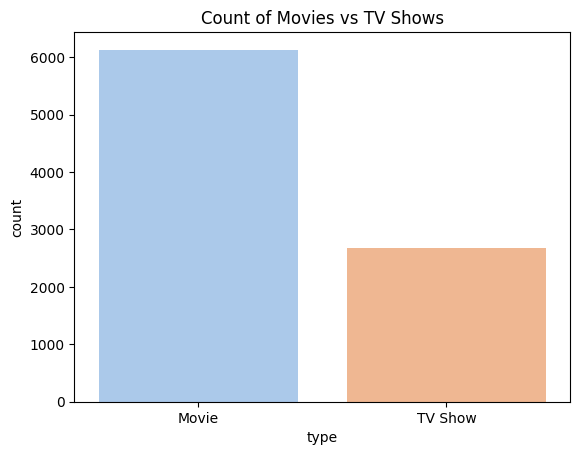

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x='type', hue='type', palette='pastel', legend=False)
plt.title('Count of Movies vs TV Shows')
plt.show()


Step 5: Ratings Distribution
Purpose: Understand how content is rated.
Summary: Most content is rated ‘TV-MA’ and ‘TV-14’, suggesting a focus on mature audiences.

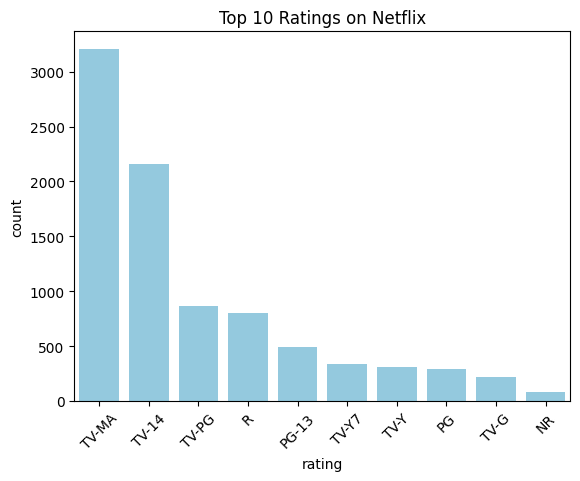

In [13]:
sns.countplot(
    data=df,
    x='rating',
    order=df['rating'].value_counts().head(10).index,
    color='skyblue'  # optional single color
)
plt.title('Top 10 Ratings on Netflix')
plt.xticks(rotation=45)
plt.show()




Step 6: Release Year Distribution
Purpose: Explore trends over time.
Summary: Content releases have grown steadily since 2010, peaking around 2018–2020.

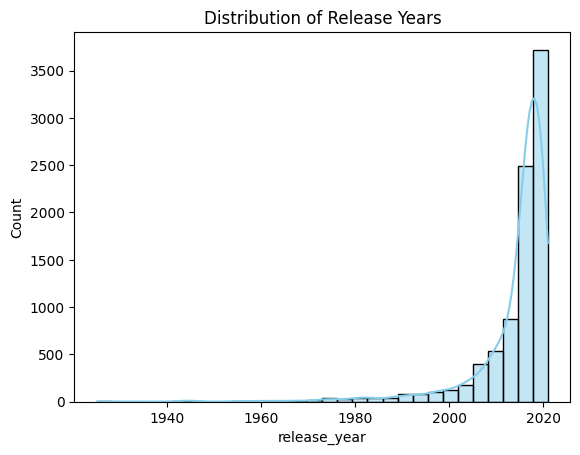

In [14]:
sns.histplot(data=df, x='release_year', bins=30, kde=True, color='skyblue')
plt.title('Distribution of Release Years')
plt.show()

Step 7: Duration Comparison by Type
Purpose: Compare movie lengths vs TV show seasons.
Summary: Most movies are around 90 minutes long, while TV shows range from 1 to 3 seasons on average.

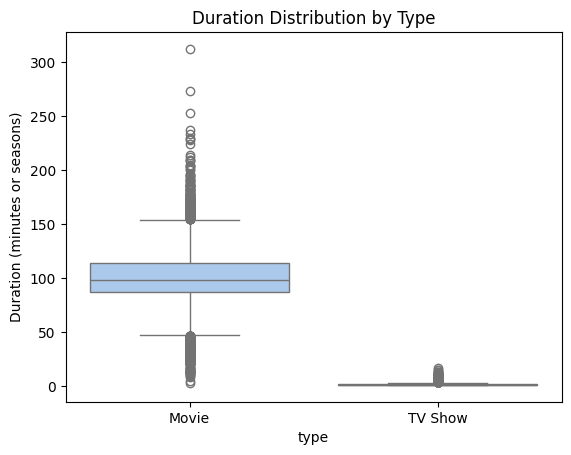

In [16]:
sns.boxplot(data=df, x='type', y='duration_int', hue='type', palette='pastel', legend=False)
plt.title('Duration Distribution by Type')
plt.ylabel('Duration (minutes or seasons)')
plt.show()



Step 8: Correlation Heatmap
Purpose: Check numeric correlations.
Summary: There is no strong correlation between release year and content duration.

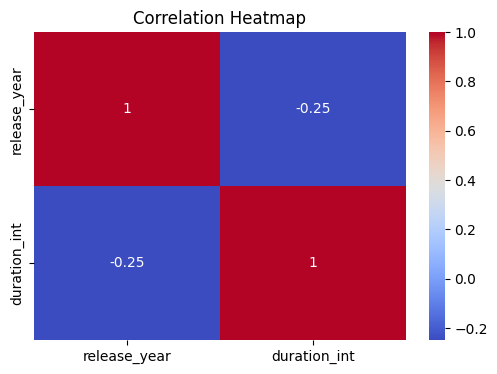

In [17]:
plt.figure(figsize=(6, 4))
sns.heatmap(df[['release_year', 'duration_int']].dropna().corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

Step 9: Pairplot for Multivariate Insight
Purpose: Explore relationships across features.
Summary: Clear separation between movies and TV shows. TV shows cluster by season count, while movie durations are more varied.

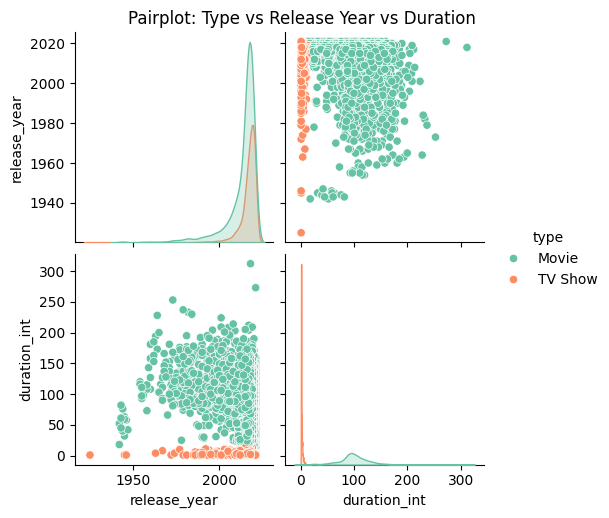

In [18]:
sns.pairplot(df[df['duration_int'].notnull()][['type', 'release_year', 'duration_int']], hue='type', palette='Set2')
plt.suptitle('Pairplot: Type vs Release Year vs Duration', y=1.02)
plt.show()

  Summary of Findings:
  
---Netflix offers more Movies than TV Shows.

----Most content is targeted at mature viewers (TV-MA, TV-14).

----Content release surged between 2015–2020.

----Movies average around 90 minutes; TV shows range between 1–3 seasons.

----Duration and release year show no significant correlation.

----The US is the leading content contributor.

Note: you may need to restart the kernel to use updated packages.
